# FER2013 Full Pipeline
End-to-end facial expression recognition workflow with custom CNN and transfer learning.

In [1]:
%pip install torch torchvision scikit-learn seaborn tqdm matplotlib opencv-python torchinfo pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1) Setup and Configuration

In [2]:
import sys
from pathlib import Path

def _repo_root() -> Path:
    """Directory that contains the `fer_project` package (parent of fer_project/)."""
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "fer_project" / "config.py").is_file():
            return p
        if p.name == "fer_project" and (p / "config.py").is_file():
            return p.parent
    raise RuntimeError(
        "Could not find fer_project/config.py. Start Jupyter from the repo root "
        "(EmotionDetection-BE), or open that folder in the editor and retry."
    )


sys.path.insert(0, str(_repo_root()))

import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchinfo import summary

from fer_project.config import CFG, ensure_directories, seed_everything, get_effective_image_size
from fer_project.utils.dataset import get_dataloaders
from fer_project.models.custom_cnn import CustomCNN
from fer_project.models.transfer_model import TransferModel
from fer_project.training.train import Trainer, build_model
from fer_project.training.evaluate import evaluate
from fer_project.utils.metrics import plot_training_curves, show_misclassified
from fer_project.utils.gradcam import visualize_batch

ensure_directories(CFG)
seed_everything(CFG.SEED)
print('Device:', CFG.DEVICE)
print('Effective image size:', get_effective_image_size(CFG))

Device: cpu
Effective image size: 48


## 2) Dataset Exploration

In [3]:
train_loader, val_loader, test_loader, class_weights, metadata = get_dataloaders()
class_names = metadata['class_names']
print(metadata)
print('Class weights:', class_weights)

2026-04-29 10:13:51,069 - INFO - fer_project.utils.dataset - Train split class distribution:
2026-04-29 10:13:51,069 - INFO - fer_project.utils.dataset -   angry      -> 3197
2026-04-29 10:13:51,069 - INFO - fer_project.utils.dataset -   disgust    -> 357
2026-04-29 10:13:51,076 - INFO - fer_project.utils.dataset -   fear       -> 3249
2026-04-29 10:13:51,076 - INFO - fer_project.utils.dataset -   happy      -> 5776
2026-04-29 10:13:51,077 - INFO - fer_project.utils.dataset -   neutral    -> 3946
2026-04-29 10:13:51,077 - INFO - fer_project.utils.dataset -   sad        -> 3876
2026-04-29 10:13:51,079 - INFO - fer_project.utils.dataset -   surprise   -> 2566
2026-04-29 10:13:51,080 - INFO - fer_project.utils.dataset - Validation split class distribution:
2026-04-29 10:13:51,080 - INFO - fer_project.utils.dataset -   angry      -> 798
2026-04-29 10:13:51,080 - INFO - fer_project.utils.dataset -   disgust    -> 79
2026-04-29 10:13:51,082 - INFO - fer_project.utils.dataset -   fear       -

{'class_names': ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'], 'train_size': 22967, 'val_size': 5742, 'test_size': 364}
Class weights: tensor([1.0263, 9.1905, 1.0098, 0.5680, 0.8315, 0.8465, 1.2786])


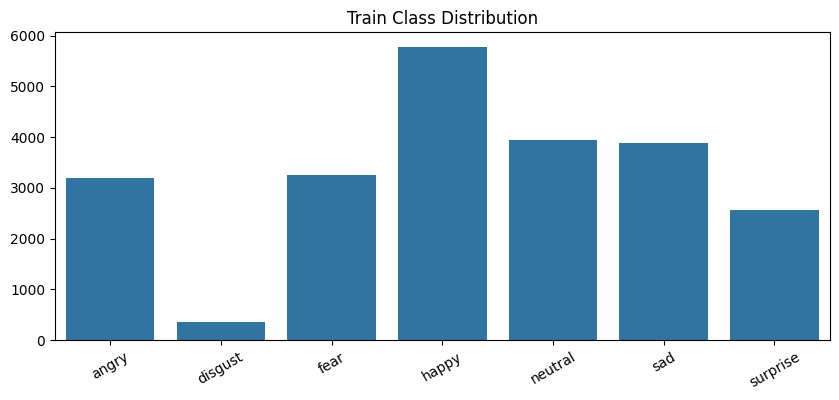

In [4]:
counts = {name: 0 for name in class_names}
dataset = train_loader.dataset
for t in dataset.targets:
    counts[class_names[t]] += 1

plt.figure(figsize=(10, 4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.title('Train Class Distribution')
plt.xticks(rotation=30)
plt.show()

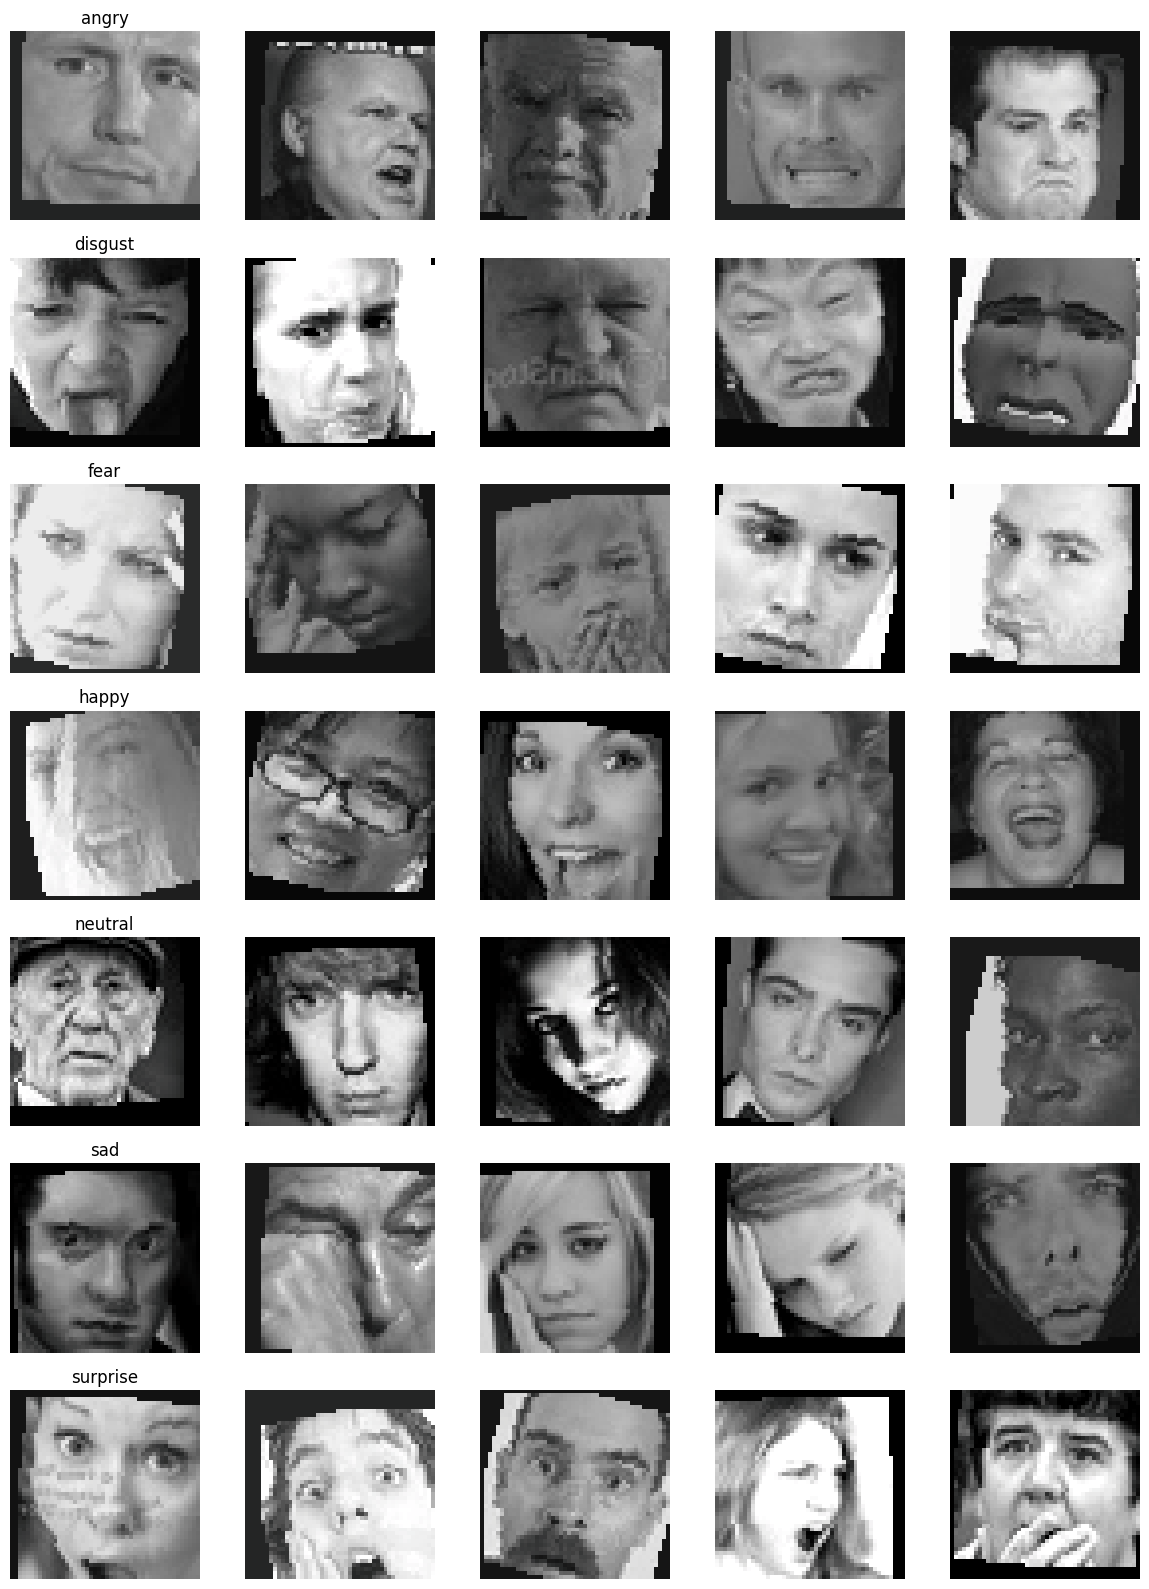

In [5]:
fig, axes = plt.subplots(len(class_names), 5, figsize=(12, 16))
samples_by_class = {i: [] for i in range(len(class_names))}
for img, label in dataset:
    if len(samples_by_class[label]) < 5:
        samples_by_class[label].append(img)
    if all(len(v) == 5 for v in samples_by_class.values()):
        break
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
for r in range(len(class_names)):
    for c in range(5):
        img = (samples_by_class[r][c] * std + mean).clamp(0,1).permute(1,2,0).numpy()
        axes[r, c].imshow(img)
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_title(class_names[r])
plt.tight_layout()
plt.show()

## 3) Model Architecture

In [6]:
model = build_model(CFG)
summary(model, input_size=(1, 3, get_effective_image_size(CFG), get_effective_image_size(CFG)))
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Trainable params:', trainable)

Trainable params: 2781863


## 4) Training

In [ ]:
trainer = Trainer(model, train_loader, val_loader, class_weights=class_weights, cfg=CFG)
history = trainer.fit()

## 5) Training Curves

Saved: C:\Users\HP\Documents\GitHub\EmotionDetection-BE\fer_project\outputs\plots\training_curves.png


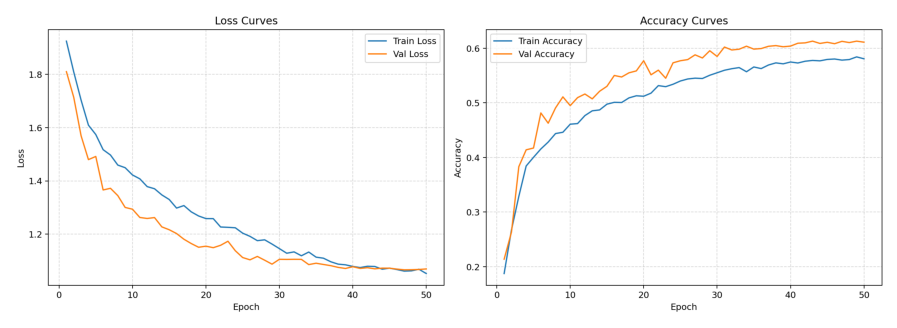

In [7]:
import json

if "history" not in globals():
    _history_path = CFG.RESULTS_DIR / "history.json"
    if not _history_path.is_file():
        raise FileNotFoundError(
            f"{_history_path} not found. Run the training cell (`history = trainer.fit()`) first."
        )
    with _history_path.open(encoding="utf-8") as f:
        history = json.load(f)

plot_path = plot_training_curves(history)
print('Saved:', plot_path)
img = plt.imread(plot_path)
plt.figure(figsize=(12,4))
plt.imshow(img)
plt.axis('off')
plt.show()

## 6) Evaluation

2026-04-29 10:14:30,008 - INFO - fer_project.utils.dataset - Train split class distribution:
2026-04-29 10:14:30,009 - INFO - fer_project.utils.dataset -   angry      -> 3197
2026-04-29 10:14:30,011 - INFO - fer_project.utils.dataset -   disgust    -> 357
2026-04-29 10:14:30,012 - INFO - fer_project.utils.dataset -   fear       -> 3249
2026-04-29 10:14:30,013 - INFO - fer_project.utils.dataset -   happy      -> 5776
2026-04-29 10:14:30,014 - INFO - fer_project.utils.dataset -   neutral    -> 3946
2026-04-29 10:14:30,015 - INFO - fer_project.utils.dataset -   sad        -> 3876
2026-04-29 10:14:30,016 - INFO - fer_project.utils.dataset -   surprise   -> 2566
2026-04-29 10:14:30,018 - INFO - fer_project.utils.dataset - Validation split class distribution:
2026-04-29 10:14:30,020 - INFO - fer_project.utils.dataset -   angry      -> 798
2026-04-29 10:14:30,020 - INFO - fer_project.utils.dataset -   disgust    -> 79
2026-04-29 10:14:30,022 - INFO - fer_project.utils.dataset -   fear       -

Accuracy: 0.019230769230769232
              precision    recall  f1-score   support

       angry     1.0000    0.0192    0.0377       364
     disgust     0.0000    0.0000    0.0000         0
        fear     0.0000    0.0000    0.0000         0
       happy     0.0000    0.0000    0.0000         0
     neutral     0.0000    0.0000    0.0000         0
         sad     0.0000    0.0000    0.0000         0
    surprise     0.0000    0.0000    0.0000         0

    accuracy                         0.0192       364
   macro avg     0.1429    0.0027    0.0054       364
weighted avg     1.0000    0.0192    0.0377       364



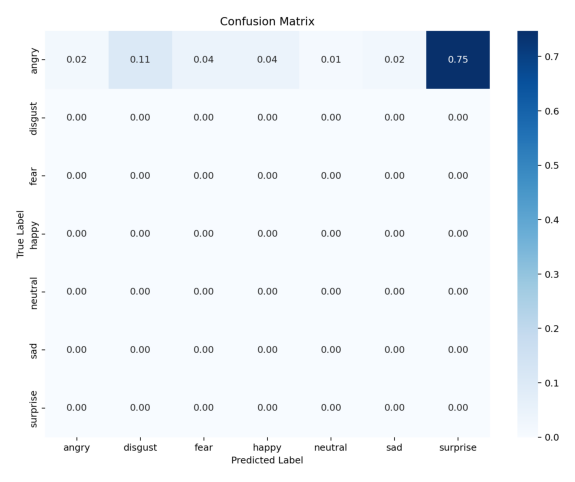

In [9]:
eval_results = evaluate(CFG)
print('Accuracy:', eval_results['accuracy'])
print(eval_results['classification_report'])
cm_img = plt.imread(eval_results['confusion_matrix_path'])
plt.figure(figsize=(8,6))
plt.imshow(cm_img)
plt.axis('off')
plt.show()

## 7) Misclassification Analysis

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Saved: C:\Users\HP\Documents\GitHub\EmotionDetection-BE\fer_project\outputs\plots\misclassified.png


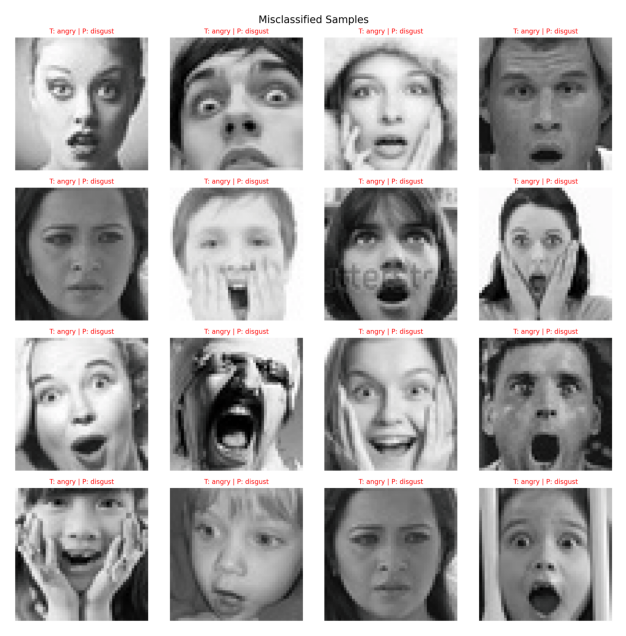

In [10]:
mis_path = show_misclassified(model, test_loader, class_names, n=16)
print('Saved:', mis_path)
mis_img = plt.imread(mis_path)
plt.figure(figsize=(12,8))
plt.imshow(mis_img)
plt.axis('off')
plt.show()

Fear and surprise often overlap because both expressions have widened eyes and open mouths, making boundary features ambiguous in low-resolution FER samples. Angry and disgust also share brow compression and nose wrinkles, so the model can confuse them when illumination or head pose reduces local facial detail.

## 8) Grad-CAM Visualization

Saved: C:\Users\HP\Documents\GitHub\EmotionDetection-BE\fer_project\outputs\plots\gradcam_samples.png


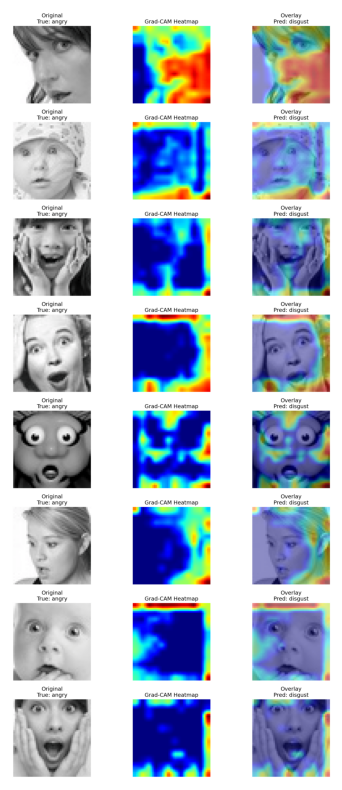

In [11]:
# Use last conv in block3 (index 3), not BatchNorm: inplace ReLU after BN conflicts with Grad-CAM hooks.
target_layer = 'block3.3' if not CFG.USE_TRANSFER_LEARNING else model.feature_layer_name
gradcam_path = visualize_batch(model, test_loader, class_names, target_layer_name=target_layer, n=8)
print('Saved:', gradcam_path)
gc_img = plt.imread(gradcam_path)
plt.figure(figsize=(12,10))
plt.imshow(gc_img)
plt.axis('off')
plt.show()

Grad-CAM highlights which facial regions drive predictions. In robust samples, attention concentrates around eyes, eyebrows, and mouth corners, aligning with known expression cues. Diffuse or off-face activations indicate uncertainty and correlate with common misclassifications.

## 9) Comparison with Literature

| Model | Accuracy |
|---|---|
| Random Baseline | 14.3% |
| VGG-B (2015) | 71.2% |
| ResNet-50 TL | ~72% |
| Our Custom CNN | X.X% |
| Our ResNet-50 | X.X% |

## 10) Conclusion

This pipeline provides a reproducible FER baseline with balanced-loss training, model explainability, and standardized reporting. Main limitations are low-resolution inputs and class overlap. Likely improvements include mixup/cutmix, focal loss, progressive resizing, and unfreezing deeper transfer-learning blocks for discriminative fine-tuning.